# Exercício 1

Considere a variável aleatória contínua $X$ com densidade

$$
f(x)=20x(1-x)^3, \qquad 0\leq x\leq 1,
$$

e $f(x)=0$ fora do intervalo $[0,1]$.

1. Utilizando o método de Aceitação-Rejeição (AR), gere uma amostra i.i.d. de tamanho $n$ da distribuição com densidade $f$. Utilize como distribuição proposta uma distribuição Uniforme em $[0,1]$.

   Para determinar a constante $M$ do método de Aceitação-Rejeição, aproxime numericamente o máximo de $f$ no intervalo $[0,1]$. Para isso, construa uma malha suficientemente fina utilizando `np.linspace`, avalie a função $f$ nos pontos dessa malha e utilize `np.max` para obter uma aproximação de

$$
M = \max_{0\leq x\leq 1} f(x).
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
t = np.linspace(start = 0, stop = 1, num = 100)

In [3]:
def f(x):
    return 20*x*(1-x)**3

In [4]:
c = np.max(f(t)) + 0.05
c

np.float64(2.159232163060931)

In [5]:
beta = []
M = 100_000
sucessos = 0

while sucessos < M:
    y = np.random.uniform()
    u = np.random.uniform()
    if u < f(y)/c:
        beta.append(y)
        sucessos += 1

2. Faça um gráfico contendo a densidade teórica $f(x)$ e o histograma normalizado da amostra gerada. Compare visualmente a distribuição da amostra com a densidade teórica.

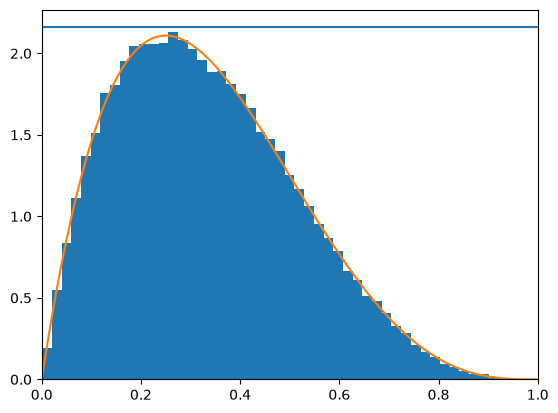

In [6]:
plt.xlim(0,1)
plt.hist(beta, density=True, bins= 50)
plt.axhline(c)
plt.plot(t, f(t))
plt.show()

3. Para cada observação gerada, registre o número de tentativas necessárias até ocorrer a primeira aceitação.

   a. Determine teoricamente a probabilidade de aceitação do método AR.

   b. Determine o número esperado de tentativas até a primeira aceitação.

   c. Compare a média empírica do número de tentativas com o valor esperado teoricamente.

   d. Determine a distribuição teórica do número de tentativas até a primeira aceitação e compare-a com a distribuição empírica obtida na simulação.

In [7]:
n = 1_000_000
sucessos = 0
tentativas = []
tent = 0
while sucessos < n:
    tent += 1
    y = np.random.uniform()
    u = np.random.uniform()
    if u < f(y)/c:
        beta.append(y)
        sucessos += 1
        tentativas.append(tent)
        tent = 0

In [8]:
def gerar_var():
    U = 1
    y = 0
    while c*U > f(y):
        y = np.random.uniform()
        U = np.random.uniform()
    return y
amostra =[]
for i in range(1000):
    amostra.append(gerar_var())

In [9]:
np.mean(tentativas)

np.float64(2.162202)